In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from neurodiffeq.generators import BaseGenerator
from scipy.stats import qmc

from neurodiffeq.conditions import IVP
from neurodiffeq import diff
from neurodiffeq.generators import Generator1D
from neurodiffeq.solvers import Solver1D, Solution1D, BundleSolution1D
from neurodiffeq.networks import FCNN
from neurodiffeq.conditions import BundleIVP 
import torch
import os
from delta_solver_mg_2 import DeltaSolver
from utils_2 import CustomCondition, f_R_reparams, _shape_manager
import yaml
import joblib
import torch.nn as nn

from scipy.stats import qmc
from neurodiffeq.solvers import BundleSolver1D
from neurodiffeq.generators import PredefinedGenerator

from scipy.constants import c as c_ms

from utils import CustomCondition, HS_reparams

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [43]:
H_0 = 70.0
h = H_0 / 100.0
Om_r_0 = 5.38*10**(-5)

Om_m_0 = 0.3
#Om_L_0 = 1.0 - Om_m_0 - Om_r_0
c_ms = 299792458.0
c = c_ms / 1000.0

#b = 1
#k_val = 0.2
#k_val1 = k_val
#k_val = k_val1 * h
Lambda = 3 * (H_0 ** 2) * (1 - Om_m_0) / c**2

# Parámetros de integración
z_0 = 20.0
z_f = 0.0
b_max = 5.0
a_0 = 1/1001.0
a_f = 1.0
N_0 = np.log(a_0)
N_f = np.log(a_f)
n_0 = abs(N_0)

N_p_0 = N_0 / n_0
N_p_f = N_f / n_0

In [44]:
model = 'Hu-Sawicki'
path = f'/home/javier-pineau/Escritorio/Tesis/Códigos Augusto/f_R_nets_for_multiuse/{model}_nets'

with open(f'{path}/saved_config.yaml') as yaml_file_f_R:
    try:
        Config_f_R = yaml.safe_load(yaml_file_f_R)
    except yaml.YAMLError as exc:
        print(exc)

# Set the range of the independent variable:
z_rescale = z_0 

z_prime_min = 0.0
z_prime_max = 1.0
z_min = z_prime_min
z_max = z_rescale * z_prime_max

# Set the range of the parameters of the bundle:
b_prime_min = float(Config_f_R['b_prime_min'])
b_prime_max = 1.0
b_max = Config_f_R['b_max']
b_min = b_prime_min * b_max

Om_m_0_min = Config_f_R['Om_m_0_min']
Om_m_0_max = Config_f_R['Om_m_0_max']

# Set neural network parameters and renormalizations:
alpha_nominator = Config_f_R['alpha_nominator']
alpha_denominator = Config_f_R['alpha_denominator']
alpha = alpha_nominator / alpha_denominator

# --- CORRECCIÓN AQUÍ: Cargar al 'device' (GPU), no a CPU ---
fR_nets = torch.load(f'{path}/nets_f_R.ph', map_location=device, weights_only=False)

f_R = f_R_reparams(z_0=z_0, b_prime_min=b_prime_min, b_max=b_max, alpha=alpha)

conditions = [
    CustomCondition(f_R.v_reparam),
    CustomCondition(f_R.r_prime_reparam)
]

r_prime_net_index = -1
v_net_index = 2

for i, net in enumerate(fR_nets):
    try:
        fR_nets[i] = net.to(device)
    except Exception:
        pass

r_prime = BundleSolution1D([fR_nets[r_prime_net_index]], [conditions[-1]])
v = BundleSolution1D([fR_nets[v_net_index]], [conditions[0]])




x_net_index = 0
x_condition = CustomCondition(f_R.x_reparam)
x_sol_obj = BundleSolution1D([fR_nets[x_net_index]], [x_condition])


def H_torch(z, theta, r_prime_sol, v_sol):
    """ Función H(z) normal (para el valor de H) """
    b, Om_m_tensor, H_0 = theta
    z_prime = 1 - (z / z_rescale)
    b_prime = (b / b_max).expand_as(z)
    
    r_val = r_prime_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False).view_as(z)
    v_val = v_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False).view_as(z)
    
    term_fR = ((1 - Om_m_tensor) / 2) * torch.exp(r_val) / v_val
    Om_L = 1.0 - Om_m_tensor - Om_r_0
    inside = Om_L + Om_m_tensor * (z+1)**3 + Om_r_0 * ((z+1)**4)
    
    H_fR = H_0 * torch.sqrt(torch.abs(term_fR))
    H_LCDM = H_0 * torch.sqrt(inside)
    
    return torch.where(z >= z_0, H_LCDM, H_fR)

def dH_dz_torch(z, theta, r_prime_sol, v_sol, x_sol):
    """
    Cálculo analítico de H'(z) optimizado para GPU.
    Reemplaza a dH_dz_red original para evitar Numpy.
    """
    b, Om_m_tensor, H_0 = theta
    
    # 1. Preparación de datos (Tensores)
    # z ya viene como tensor con gradiente
    z_prime = 1 - (z / z_rescale)
    
    # Broadcasting de b (tensor)
    b_prime = (b / b_max).expand_as(z)
    
    # 2. Inferencia de Redes (to_numpy=False mantiene GPU)
    # Obtenemos r, v, x directamente en la GPU
    r_prime_val = r_prime_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False)
    v_val = v_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False)
    x_val = x_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False)

    # Aseguramos formas
    r_prime_val = r_prime_val.view_as(z)
    v_val = v_val.view_as(z)
    x_val = x_val.view_as(z)

    # r físico = exp(r_prime_net)
    r_phys = torch.exp(r_prime_val)
    
    numer = (r_phys + b) * (((r_phys + b) ** 2) - 2.0 * b)
    denom_gamma = 4.0 * b * r_phys
    Gamma = numer / denom_gamma
    
    denom_z = z + 1.0

    dr_dz = - r_phys * Gamma * x_val / denom_z
    dv_dz = - v_val * (x_val * Gamma + 4.0 - 2.0 * v_val) / denom_z


    coef1 = 0.25 * (1.0 - Om_m_tensor)
    
    term_inside_sqrt = (r_phys / (2.0 * v_val)) * (1.0 - Om_m_tensor)
    coef2 = torch.sqrt(term_inside_sqrt)
    
    term_deriv = (dr_dz / v_val) - (r_phys * dv_dz / (v_val ** 2))
    
    dH_fR = H_0 * (coef1 / coef2) * term_deriv

    Om_L = 1.0 - Om_m_tensor - Om_r_0
    
    inside = Om_L + Om_m_tensor * (z+1)**3 + Om_r_0 * ((z+1)**4)
    afuera = 3 * Om_m_tensor * (z+1)**2 + 4 * Om_r_0 * ((z+1)**3)
    
    dH_LCDM = H_0 * afuera / (2 * torch.sqrt(inside))

    mask = (z >= z_0)
    dH_final = torch.where(mask, dH_LCDM, dH_fR)
    
    return dH_final


def Geff_torch(z, k, theta, Lambda_val, r_prime_sol):
    """ Función Geff(z) optimizada """
    b, Om_m_tensor, H_0 = theta
    z_prime = 1 - (z / z_rescale)
    b_prime = (b / b_max).expand_as(z)
    
    r_val = r_prime_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False).view_as(z)
    r_prime_exp = torch.exp(r_val)

    denomFR = 1.0 + (r_prime_exp * Lambda_val) / (Lambda_val * b)
    FR = 1.0 - 2.0 / (b * (denomFR ** 2))
    FRR = 4.0 / (Lambda_val * (b**2) * (denomFR ** 3))

    m = FRR / FR
    epsilon = (k**2) * ((1.0 + z)**2) * m
    term = 1.0 / (3.0 + 1.0 / epsilon)
    Geff_over_G = (1.0 / FR) * (1.0 + term)

    mask = (z >= z_0)
    return torch.where(mask, torch.ones_like(Geff_over_G), Geff_over_G)



# $\Omega_m$ , k , b

In [ ]:
class BundleLHSGenerator(BaseGenerator):
    def __init__(self, batch_size, t_min, t_max, Om_min, Om_max, 
                 k_min, k_max, b_min, b_max, device='cpu'):
        super().__init__()
        self.size = batch_size
        self.bounds_low  = [t_min,  Om_min, k_min,  b_min]
        self.bounds_high = [t_max,  Om_max, k_max,  b_max]
        self.device = device
        self.sampler = qmc.LatinHypercube(d=4)

    def get_examples(self):
        sample = self.sampler.random(n=self.size)
        scaled = qmc.scale(sample, self.bounds_low, self.bounds_high)
        tensors = [
            torch.tensor(scaled[:, i], dtype=torch.float64,  # <-- float64
                         requires_grad=True, device=self.device).reshape(-1, 1)
            for i in range(4)
        ]
        return tensors

def ODE_MG_NN_Bundle_3params(X, X_p, N_p, Om_m_tensor, k_tensor, b_tensor, H_0):
    N = N_p * n_0 
    a = torch.exp(N)
    z = (1.0 / a) - 1.0

    # Lambda recalculada por punto con Om_m_tensor del bundle
    Lambda_tensor = 3.0 * (H_0 ** 2) * (1.0 - Om_m_tensor) / c**2

    theta_bundle = [b_tensor, Om_m_tensor, H_0]

    H_t  = H_torch(z, theta_bundle, r_prime, v)
    mu_t = Geff_torch(z, k_tensor, theta_bundle, Lambda_tensor, r_prime)

    dH_dz = dH_dz_torch(z, theta_bundle, r_prime, v, x_sol_obj)
    dH_da = dH_dz * (-1.0 / (a ** 2))

    mu_t = torch.nan_to_num(mu_t, nan=1.0, posinf=1.0, neginf=1.0)

    H_t      = H_t.view(-1, 1)
    dH_t     = dH_da.view(-1, 1)
    mu_t     = mu_t.view(-1, 1)
    Om_m_col = Om_m_tensor.view(-1, 1)

    denom = (H_t ** 2) * (a ** 3)
    term1 = n_0 * ((dH_t / H_t) * a + 2)
    pref  = (3 * Om_m_col * (n_0 ** 2) * (H_0 ** 2)) / 2
    term2 = pref * (mu_t / denom)

    res1 = diff(X, N_p) - X_p
    res2 = diff(X_p, N_p) + (X_p ** 2) + (term1 * X_p) - term2

    return [res1, res2]


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 128

k_min_fisico = 0.006
k_max_fisico = 0.2

Om_min, Om_max = 0.1,      0.4
k_min,  k_max  = k_min_fisico * h, k_max_fisico * h
b_min,  b_max  = 0.001,      0.5
capas = (32, 32, 32, 32)
lr = 1e-4

train_gen = BundleLHSGenerator(
    batch_size, N_p_0, N_p_f, Om_min, Om_max, k_min, k_max, b_min, b_max, device=device
)
valid_gen = BundleLHSGenerator(
    batch_size, N_p_0, N_p_f, Om_min, Om_max, k_min, k_max, b_min, b_max, device=device
)

# ---- Redes ----
nets = [FCNN(n_input_units=4, hidden_units=capas).double().to(device) for _ in range(2)]
adam = torch.optim.Adam(
    set([p for net in nets for p in net.parameters()]), lr=lr
)

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0,  n_0)]

def weighted_loss(res, x, t):
    return (res**2).mean()

solver = BundleSolver1D(
    ode_system=lambda X, X_p, N_p, Om_gen, k_gen, b_gen: ODE_MG_NN_Bundle_3params(
        X, X_p, N_p, Om_gen, k_gen, b_gen, H_0
    ),
    nets=nets,
    conditions=condition,
    t_min=N_p_0, t_max=N_p_f,
    n_batches_valid=0,
    theta_min=(Om_min, k_min,  b_min),
    theta_max=(Om_max, k_max,  b_max),
    eq_param_index=(0, 1, 2),
    optimizer=adam,
    train_generator=train_gen,
    valid_generator=valid_gen,
    loss_fn=weighted_loss,
)

iterations = 1000000
solver.fit(iterations)

nombre_red = f'Bundle Om entre {Om_min} y {Om_max}, k entre {k_min} y {k_max}, b entre {b_min} y {b_max}, lr={lr}, iter={iterations}, batch={batch_size}, hidden={capas}'
loss = solver.metrics_history['train_loss']

# Save
save_dir = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(np.arange(len(loss)), loss, label='Loss')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
#plt.title(f'Loss (Bundle Om, b={b_fixed}, k={k_val})')
plt.savefig(os.path.join(save_dir, f"{nombre_red}.png"))
plt.show()

save_path = os.path.join(save_dir, nombre_red + ".pt")
# Nota: weights_only=False suele ser necesario para guardar diccionarios completos
torch.save(solver._get_internal_variables()['best_nets'], save_path)
print(f"Mejores redes guardadas en: {save_path}")

Training Progress:   0%|          | 0/1000000 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Comparaciones

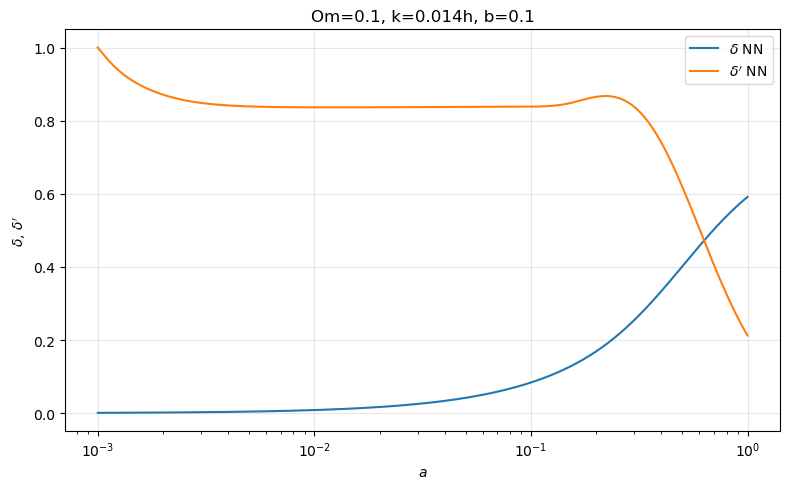

In [46]:
import types

device = torch.device('cpu')
save_path = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle/Bundle Om entre 0.1 y 0.4, k entre 0.0042 y 0.13999999999999999, b entre 0.001 y 0.5, lr=0.0001, iter=1000000, batch=128, hidden=(32, 32, 32, 32).pt"
nets = torch.load(save_path, map_location=device, weights_only=False)
for net in nets:
    net.to('cpu'); net.double(); net.eval()

# Parche: forzar coordinates a CPU antes de pasarlas a la red
def enforce_cpu(self, net, *coordinates):
    coords_cpu = [c.to('cpu') if torch.is_tensor(c) else torch.tensor(c, dtype=torch.float64, device='cpu') for c in coordinates]
    network_output = net(torch.cat(coords_cpu, dim=1))
    return self.parameterize(network_output, *coords_cpu)

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0,  n_0)]

# Aplicar parche a cada condición
for cond in condition:
    cond.enforce = types.MethodType(enforce_cpu, cond)

sol = BundleSolution1D(nets, condition)

# Evaluación
Om_m_0_plot = 0.1
k_plot       = 0.01 
b_plot       = 0.1

def x_bundle(N_vec, Om_m_0, k, b):
    Om_vec = Om_m_0 * np.ones_like(N_vec)
    k_vec  = k      * np.ones_like(N_vec)
    b_vec  = b      * np.ones_like(N_vec)
    return sol(N_vec, Om_vec, k_vec, b_vec, to_numpy=True)[0]

def y_bundle(N_vec, Om_m_0, k, b):
    Om_vec = Om_m_0 * np.ones_like(N_vec)
    k_vec  = k      * np.ones_like(N_vec)
    b_vec  = b      * np.ones_like(N_vec)
    return sol(N_vec, Om_vec, k_vec, b_vec, to_numpy=True)[1]

N_vec = np.linspace(N_p_0, N_p_f, 10000)
a_vec = np.exp(n_0 * N_vec)

x_nn = x_bundle(N_vec, Om_m_0_plot, k_plot, b_plot)
y_nn = y_bundle(N_vec, Om_m_0_plot, k_plot, b_plot)

delta_nn   = np.exp(x_nn)
delta_p_nn = np.exp(x_nn) * y_nn / (n_0 * a_vec)

plt.figure(figsize=(8, 5))
plt.plot(a_vec, delta_nn,   label=r'$\delta$ NN')
plt.plot(a_vec, delta_p_nn, label=r"$\delta'$ NN")
plt.xscale('log')
plt.xlabel(r'$a$')
plt.ylabel(r'$\delta$, $\delta^\prime$')
plt.title(f'Om={Om_m_0_plot}, k={k_plot/h:.3f}h, b={b_plot}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_53656/3671780093.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left')
/tmp/ipykernel_53656/3671780093.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='lower right')
/tmp/ipykernel_53656/3671780093.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='center left', fontsize=25)


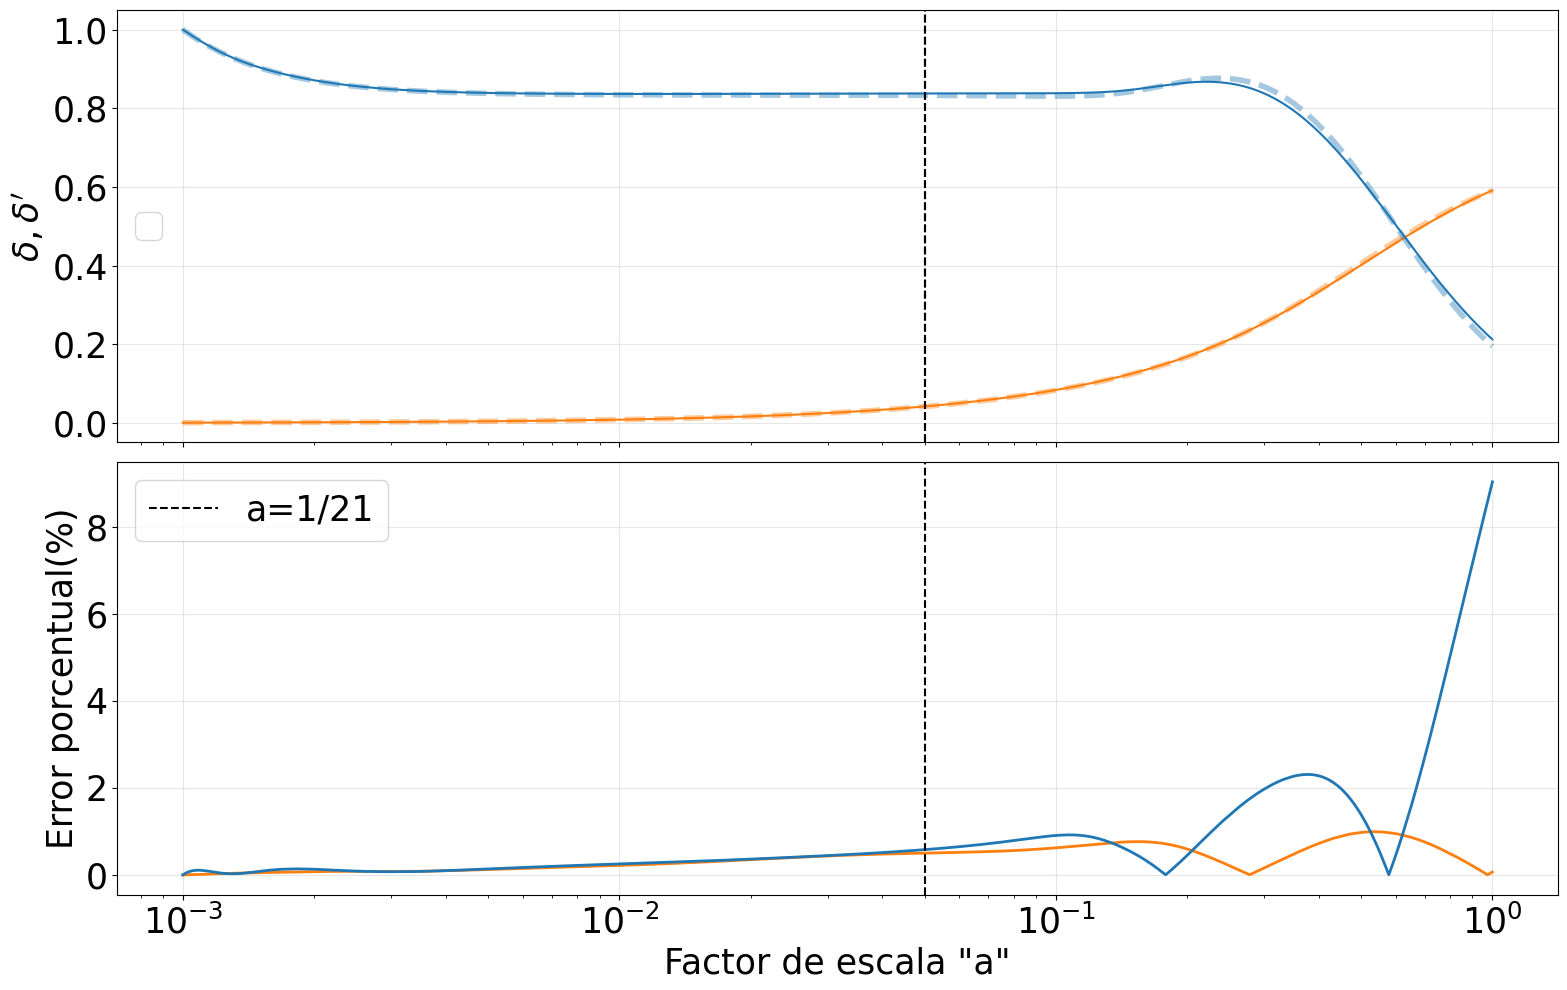

In [47]:


solver_clase = DeltaSolver(Om_m_0=Om_m_0_plot, b=b_plot, k=k_plot/h) #, H0=H0_plot)
#                                                           ^^^^^^^
#                                                     sin factor h, igual que antes
solver_clase.z_ini_HS = z_0  
num_points = 1000
H_interp, Hprime_interp, r_interp = solver_clase.H_HS()
a_mg, delta_mg, delta_p_mg = solver_clase.solve_delta_mg(num_points=num_points)
delta_mg_interp   = interp1d(a_mg, delta_mg, bounds_error=False, fill_value="extrapolate")
delta_p_mg_interp = interp1d(a_mg, delta_p_mg, bounds_error=False, fill_value="extrapolate")

delta_num = delta_mg_interp(a_vec)
delta_p_num = delta_p_mg_interp(a_vec)

diff_delta = 100 * np.abs((delta_nn - delta_num) / delta_num)
diff_delta_p = 100 * np.abs((delta_p_nn - delta_p_num) / delta_p_num)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 10))
c_d, c_p = 'tab:orange', 'tab:blue'


ax1.plot(a_vec, delta_nn, color=c_d, ls='-', lw=1.5) #, label=r'$\delta_m$ NN')
ax1.plot(a_vec, delta_p_nn, color=c_p, ls='-', lw=1.5)#, label=r'$\delta^\prime_m$ NN')
ax1.plot(a_vec, delta_num,  color=c_d, ls='--', lw=4, alpha=0.4)#, label=r'$\delta_m$ Num (Clase)')
ax1.plot(a_vec, delta_p_num, color=c_p, ls='--', lw=4, alpha=0.4)#, label=r'$\delta^\prime_m$ Num (Clase)')
ax1.axvline(x=1/20, color='black', linestyle='--')#, label = 'a=1/21', linewidth=1)


ax1.set_xscale('log'); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('a'); ax1.set_ylabel(r'$\delta, \delta^\prime$')
ax1.legend(loc='upper left')


ax2.plot(a_vec, diff_delta, color=c_d, ls='-', lw=2)#, label=r'Error $\delta$')
ax2.plot(a_vec, diff_delta_p, color=c_p, ls='-', lw=2)#, label=r'Error $\delta^\prime$')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

ax1.axvline(x=1/20, color='black', linestyle='--') #, label = 'a=1/21', linewidth=1)
ax2.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21') #, linewidth=1)


ax1.set_ylabel(r'$\delta, \delta^\prime$', fontsize=25)
ax2.set_xlabel(r'Factor de escala "a"', fontsize = 25)
ax2.set_ylabel('Error porcentual(%)', fontsize=25)

ax2.tick_params(axis='x', labelsize=25) 

ax1.tick_params(axis='y', labelsize=25) 
ax2.tick_params(axis='y', labelsize=25) 
ax2.grid(True, alpha=0.3)

# Leyenda para el gráfico inferior
# Example: Make the legend bigger
ax1.legend(loc='center left', fontsize=25)
ax2.legend(loc='upper left', fontsize=25)
#ax2.set_xlim(0, 1/21)

#ax2.set_ylim(0, 1)
plt.tight_layout()

#
# plt.savefig(f'solución bundle más diferencia H num Om = {Om_m_0}, b={b}, k={k_val1}.png')

plt.show()

Resolviendo ODE numérica...


/tmp/ipykernel_53656/2555533099.py:147: RuntimeWarning: overflow encountered in exp
  r_prime_exp = np.exp(r_prime_sol)
/tmp/ipykernel_53656/2555533099.py:159: RuntimeWarning: divide by zero encountered in divide
  term = 1.0 / (3.0 + 1.0 / epsilon)
/tmp/ipykernel_53656/2555533099.py:151: RuntimeWarning: overflow encountered in square
  FR = 1.0 - 2.0 / (b * (denomFR ** 2))
/tmp/ipykernel_53656/2555533099.py:152: RuntimeWarning: overflow encountered in power
  FRR = 4.0 / (Lambda_val * b**2 * (denomFR ** 3))


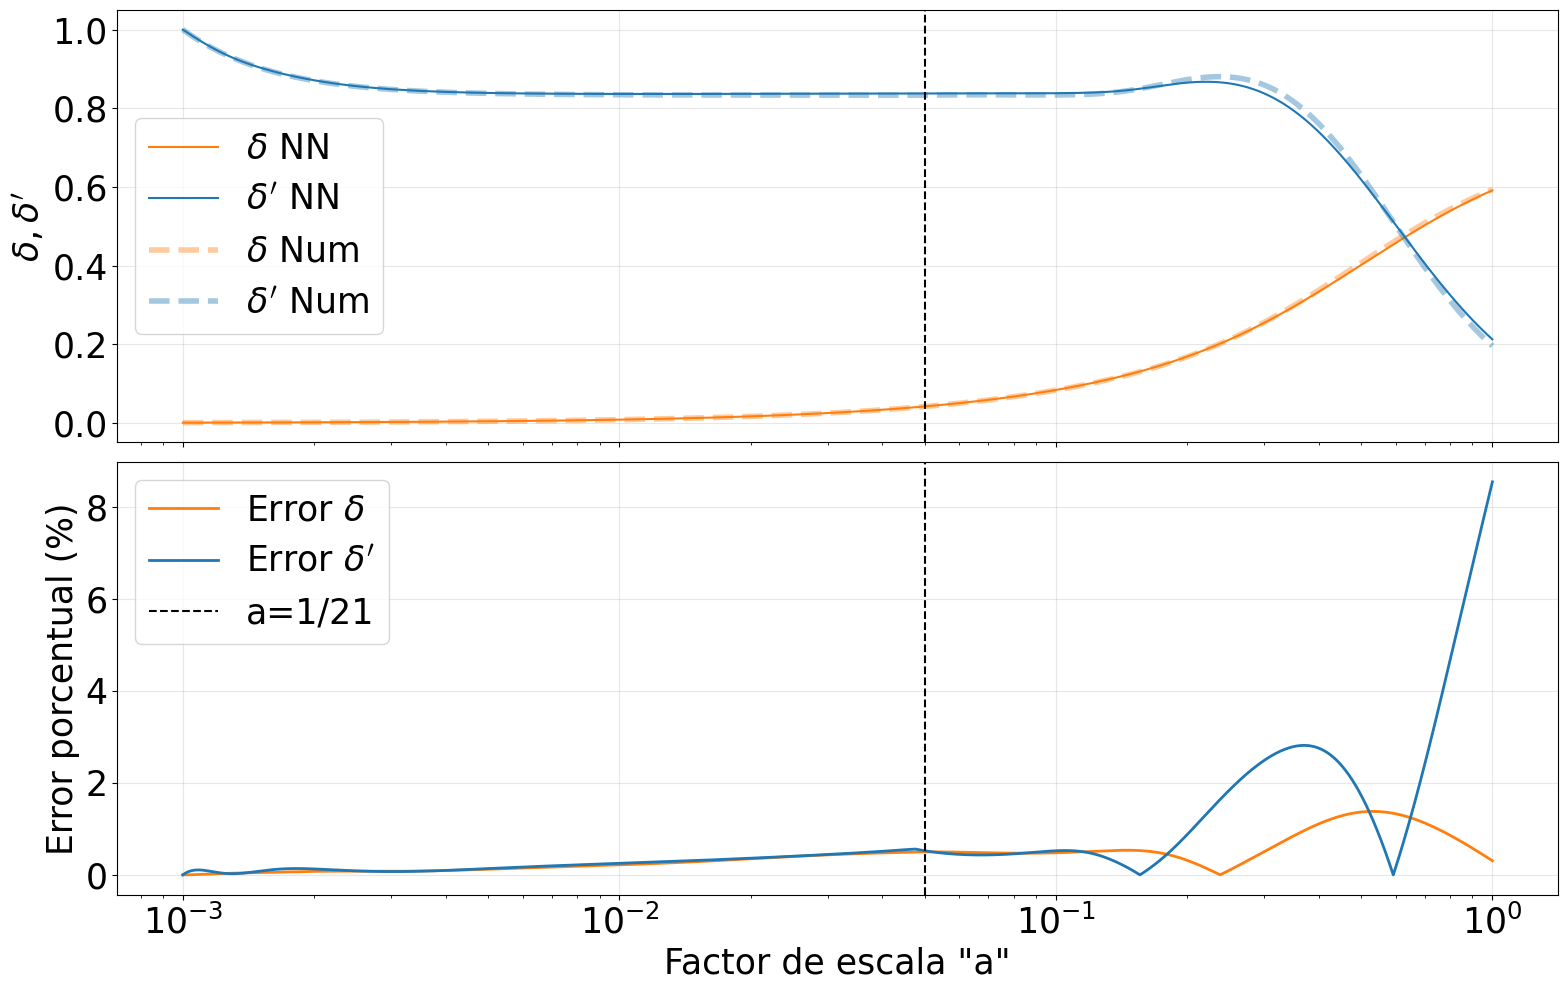

In [48]:
# ---- Parámetros (deben coincidir con los del plot) ----
Om_m_0  = Om_m_0_plot
b       = b_plot
k_val   = k_plot        # ya en unidades físicas (h/Mpc)
k_val1  = k_plot   # en unidades de h/Mpc, para el nombre del archivo
#H_0     = H0_plot
Om_L_0  = 1.0 - Om_m_0 - Om_r_0
Lambda  = 3 * (H_0 ** 2) * (1 - Om_m_0) / c**2

model = 'Hu-Sawicki'
path = f'/home/javier-pineau/Escritorio/Tesis/Códigos Augusto/f_R_nets_for_multiuse/{model}_nets'

with open(f'{path}/saved_config.yaml') as yaml_file_f_R:
    try:
        Config_f_R = yaml.safe_load(yaml_file_f_R)
    except yaml.YAMLError as exc:
        print(exc)

# Set the range of the independent variable:

z_rescale = z_0

z_prime_min = 0.0
z_prime_max = 1.0
z_min = z_prime_min
z_max = z_rescale * z_prime_max

# Set the range of the parameters of the bundle:
b_prime_min = float(Config_f_R['b_prime_min'])
b_prime_max = 1.0
b_max = Config_f_R['b_max']
b_min = b_prime_min * b_max

Om_m_0_min = Config_f_R['Om_m_0_min']
Om_m_0_max = Config_f_R['Om_m_0_max']

# Set neural network parameters and renormalizations:
alpha_nominator = Config_f_R['alpha_nominator']
alpha_denominator = Config_f_R['alpha_denominator']
alpha = alpha_nominator / alpha_denominator

# Cargar solo las redes necesarias para H(z)
nets = torch.load(f'{path}/nets_f_R.ph', map_location=torch.device('cpu'), weights_only=False)

f_R = f_R_reparams(z_0=z_0, b_prime_min=b_prime_min, b_max=b_max, alpha=alpha)

conditions = [
    CustomCondition(f_R.v_reparam),
    CustomCondition(f_R.r_prime_reparam)
 ]

r_prime_net_index = -1
v_net_index = 2

r_prime = BundleSolution1D([nets[r_prime_net_index]], [conditions[-1]])
v = BundleSolution1D([nets[v_net_index]], [conditions[0]])

def H(z, theta, **kwargs):
    """Función que calcula el parámetro de Hubble H(z)"""
    b, Om_m_0, H_0 = theta  
    
    z_prime = 1 - (z / z_rescale)
    b_prime = b / b_max

    if kwargs.pop('post', False):
        z_prime = z_prime * np.ones_like(b_prime)
        no_reshape = False
    else:
        shape, no_reshape = _shape_manager(z, b, Om_m_0)
        b_prime = b_prime * shape
        Om_m_0 = Om_m_0 * shape

    # --- DEVICE & DTYPE FIX: ensure all tensors are on the same device and dtype as the network ---
    net_device = next(r_prime.nets[0].parameters()).device
    net_dtype = next(r_prime.nets[0].parameters()).dtype
    import torch
    def to_tensor_on_device_dtype(arr):
        if isinstance(arr, np.ndarray):
            return torch.tensor(arr, dtype=net_dtype, device=net_device)
        elif isinstance(arr, float) or isinstance(arr, int):
            return torch.tensor([arr], dtype=net_dtype, device=net_device)
        elif torch.is_tensor(arr):
            return arr.to(device=net_device, dtype=net_dtype)
        else:
            return arr

    z_prime_t = to_tensor_on_device_dtype(z_prime)
    b_prime_t = to_tensor_on_device_dtype(b_prime)
    Om_m_0_t = to_tensor_on_device_dtype(Om_m_0)

    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)

    out = H_0 * np.sqrt(((1 - Om_m_0) / 2) * np.exp(r_prime_sol) / v_sol)

    if no_reshape:
        out = out[0][0]
    return out



z_examples = np.linspace(0, z_0, 10000) # Hay que hacer que coincida con los que uso para entrenar la red. 

theta_example = [b, Om_m_0, H_0]


H_values = H(z_examples, theta_example)

solver_clase = DeltaSolver(Om_m_0=Om_m_0, b=b, k=k_val1)
solver_clase.z_ini_HS = z_0  

H_interp, Hprime_interp, r_interp = solver_clase.H_HS()

def Geff_G_func(z, k, b, Om_m_0, Lambda_val, debug=False, **kwargs):
    z_prime = 1 - (z / z_rescale)
    b_prime = b / b_max

    if kwargs.pop('post', False):
        z_prime = z_prime * np.ones_like(b_prime)
        no_reshape = False
    else:
        shape, no_reshape = _shape_manager(z, b, Om_m_0)
        b_prime = b_prime * shape
        Om_m_0 = Om_m_0 * shape

    # --- DEVICE & DTYPE FIX: ensure all tensors are on the same device and dtype as the network ---
    net_device = next(r_prime.nets[0].parameters()).device
    net_dtype = next(r_prime.nets[0].parameters()).dtype
    
    def to_tensor_on_device_dtype(arr):
        if isinstance(arr, np.ndarray):
            return torch.tensor(arr, dtype=net_dtype, device=net_device)
        elif isinstance(arr, float) or isinstance(arr, int):
            return torch.tensor([arr], dtype=net_dtype, device=net_device)
        elif torch.is_tensor(arr):
            return arr.to(device=net_device, dtype=net_dtype)
        else:
            return arr

    z_prime_t = to_tensor_on_device_dtype(z_prime)
    b_prime_t = to_tensor_on_device_dtype(b_prime)
    Om_m_0_t = to_tensor_on_device_dtype(Om_m_0)

    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)

    r_prime_exp = np.exp(r_prime_sol)

    denomFR = 1.0 + (r_prime_exp * Lambda_val) / (Lambda_val * b)  

    FR = 1.0 - 2.0 / (b * (denomFR ** 2))
    FRR = 4.0 / (Lambda_val * b**2 * (denomFR ** 3))

    m = FRR / FR
    
    # CORRECCIÓN: Usamos 'k' (el argumento de la función) en lugar de 'k_val'
    epsilon = (k**2) * (1.0 + z)**2 * m

    term = 1.0 / (3.0 + 1.0 / epsilon)
    Geff_over_G = (1.0 / FR) * (1.0 + term)

    return Geff_over_G


x_net_index = 0
x_condition = CustomCondition(f_R.x_reparam)
x = BundleSolution1D([nets[x_net_index]], [x_condition])

def dH_dz_red(z, theta):
    b, Om_m_0, H_0_local = theta

    z = np.asarray(z)
    z_prime = 1 - (z / z_rescale)
    b_prime = np.full_like(z, b / b_max)
    Om_m_0_arr = np.full_like(z, Om_m_0)

    # Ensure correct device and dtype for all network inputs
    net_device = next(r_prime.nets[0].parameters()).device
    net_dtype = next(r_prime.nets[0].parameters()).dtype
    import torch
    def to_tensor_on_device_dtype(arr):
        if isinstance(arr, np.ndarray):
            return torch.tensor(arr, dtype=net_dtype, device=net_device)
        elif isinstance(arr, float) or isinstance(arr, int):
            return torch.tensor([arr], dtype=net_dtype, device=net_device)
        elif torch.is_tensor(arr):
            return arr.to(device=net_device, dtype=net_dtype)
        else:
            return arr

    z_prime_t = to_tensor_on_device_dtype(z_prime)
    b_prime_t = to_tensor_on_device_dtype(b_prime)
    Om_m_0_t = to_tensor_on_device_dtype(Om_m_0_arr)

    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=False)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=False)
    x_sol = x(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=False)

    dtype = r_prime_sol.dtype
    device = r_prime_sol.device

    r = torch.exp(r_prime_sol)
    b_tensor = torch.as_tensor(b_prime * b_max, dtype=dtype, device=device)
    Om_m_0_tensor = torch.as_tensor(Om_m_0_arr, dtype=dtype, device=device)
    z_tensor = torch.as_tensor(z, dtype=dtype, device=device)

    Gamma = (r + b_tensor) * (((r + b_tensor) ** 2) - 2.0 * b_tensor) / (4.0 * b_tensor * r)
    denom = z_tensor + 1.0

    dr_dz = - r * Gamma * x_sol / denom
    dv_dz = - v_sol * (x_sol * Gamma + 4.0 - 2.0 * v_sol) / denom

    coef1 = 0.25 * (1.0 - Om_m_0_tensor)
    coef2 = torch.sqrt(r / (2.0 * v_sol) * (1.0 - Om_m_0_tensor))

    dH = coef1 / coef2 * (dr_dz / v_sol - r * dv_dz / (v_sol ** 2))
    return dH.detach().cpu().numpy()

theta_example = [b, Om_m_0, H_0]

dH_net_values = H_0 * dH_dz_red(z_examples, theta_example)


H_interp_class, Hprime_interp_class, r_interp_class = solver_clase.H_HS()
z_range_class = np.linspace(0, solver_clase.z_ini_HS, 10000)
H_class = H_interp_class(z_range_class) * H_0  
r_class = r_interp_class(z_range_class)
z_vec_class, x_vec_class, v_vec_class, r_vec_class = solver_clase.integ_HS()
v_interp_class = interp1d(z_vec_class, v_vec_class, bounds_error=False, fill_value="extrapolate")
v_class = v_interp_class(z_range_class)


dH_dz_clase_values =H_0* solver_clase.dH_dz(z=z_range_class, r=r_class, v=v_class, x=x_vec_class)
dH_dz_clase_values = np.asarray(dH_dz_clase_values)
dH_net_values = np.asarray(dH_net_values)


dH_interp_class_to_examples = interp1d(z_range_class, dH_dz_clase_values, bounds_error=False, fill_value="extrapolate")

dH_dz_clase = dH_interp_class_to_examples(z_examples)

# Derivadas de red + expresión analítica de LCDM pegadas

def H_LCDM(a):
    inside = Om_L_0 + Om_m_0 / (a ** 3) + Om_r_0 / (a ** 4)
    return H_0 * np.sqrt(inside)

def dH_da_LCDM(a):
    numerator = -3.0 * Om_m_0 * (a ** (-4)) - 4 * Om_r_0 * (a ** (-5))
    raiz = np.sqrt(Om_L_0 + Om_m_0 / (a ** 3) + Om_r_0 / (a ** 4))
    dHda_ana = H_0 * numerator / (2 * raiz)
    return dHda_ana


z_lcdm = np.linspace(z_0, 1000, 10000)

# ---- Tramo LCDM (z > z_0) ----
def H_LCDM(a):
    return H_0 * np.sqrt(Om_L_0 + Om_m_0 / a**3 + Om_r_0 / a**4)

def dH_da_LCDM(a):
    raiz = np.sqrt(Om_L_0 + Om_m_0 / a**3 + Om_r_0 / a**4)
    return H_0 * (-3*Om_m_0*a**(-4) - 4*Om_r_0*a**(-5)) / (2 * raiz)

z_lcdm   = np.linspace(z_0, 1000, 10000)
da_dz    = -1.0 / (1.0 + z_lcdm)**2
H_lcdm   = H_LCDM(1.0 / (1.0 + z_lcdm))
dH_lcdm  = dH_da_LCDM(1.0 / (1.0 + z_lcdm)) * da_dz

# ---- Combinar tramos ----
z_comb    = np.concatenate((z_examples,    z_lcdm[1:]))
H_comb    = np.concatenate((H_values,      H_lcdm[1:]))
dH_comb   = np.concatenate((dH_net_values, dH_lcdm[1:]))
order     = np.argsort(z_comb)
z_total   = z_comb[order]
H_total   = H_comb[order]
dH_total  = dH_comb[order]

# ---- ODE numérica con solve_ivp ----
def ODE_MG_num_Hred(N_p, x_val, k_param, b_param, Om_param, Lam_param):
    N        = N_p * n_0
    a        = np.exp(N)
    z_scalar = 1.0/a - 1.0

    H_z   = np.interp(z_scalar, z_total, H_total)
    dHdz  = np.interp(z_scalar, z_total, dH_total)
    dHda  = dHdz * (-1.0 / a**2)

    mu_res = Geff_G_func(z_scalar, k_param, b_param, Om_param, Lam_param)
    mu_val = float(mu_res.item() if hasattr(mu_res, 'item') else mu_res)
    if z_scalar > z_0:
        mu_val = 1.0

    term1  = n_0 * ((dHda / H_z) * a + 2)
    denom  = (H_z**2) * (a**3)
    term2  = 1.5 * (Om_param * n_0**2 * H_0**2) * (mu_val / denom)

    return [x_val[1], -x_val[1]**2 - term1*x_val[1] + term2]

N_eval   = np.linspace(N_p_0, N_p_f, 10000)
y0_num   = [-n_0, n_0]

print("Resolviendo ODE numérica...")
sol_num = solve_ivp(
    fun=ODE_MG_num_Hred,
    t_span=[N_p_0, N_p_f],
    y0=y0_num,
    t_eval=N_eval,
    method='RK45',
    args=(k_plot, b_plot, Om_m_0_plot, Lambda),
    rtol=1e-10, atol=1e-12
)

a_num        = np.exp(sol_num.t * n_0)
delta_num    = np.exp(sol_num.y[0])
delta_p_num  = delta_num * sol_num.y[1] / (n_0 * a_num)

# ---- Interpolar numérico en a_vec (mismo vector que la red) ----
delta_num_i   = np.interp(a_vec, a_num, delta_num)
delta_p_num_i = np.interp(a_vec, a_num, delta_p_num)

# ---- Diferencias porcentuales ----
diff_delta   = 100 * np.abs((delta_nn   - delta_num_i)   / delta_num_i)
diff_delta_p = 100 * np.abs((delta_p_nn - delta_p_num_i) / delta_p_num_i)

# ---- Plot ----
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 10))
c_d, c_p = 'tab:orange', 'tab:blue'

ax1.plot(a_vec, delta_nn,     color=c_d, ls='-',  lw=1.5, label=r'$\delta$ NN')
ax1.plot(a_vec, delta_p_nn,   color=c_p, ls='-',  lw=1.5, label=r'$\delta^\prime$ NN')
ax1.plot(a_vec, delta_num_i,  color=c_d, ls='--', lw=4, alpha=0.4, label=r'$\delta$ Num')
ax1.plot(a_vec, delta_p_num_i,color=c_p, ls='--', lw=4, alpha=0.4, label=r'$\delta^\prime$ Num')
ax1.axvline(x=1/20, color='black', linestyle='--')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.set_ylabel(r'$\delta, \delta^\prime$', fontsize=25)
ax1.legend(loc='center left', fontsize=25)
ax1.tick_params(axis='y', labelsize=25)

ax2.plot(a_vec, diff_delta,   color=c_d, ls='-', lw=2, label=r'Error $\delta$')
ax2.plot(a_vec, diff_delta_p, color=c_p, ls='-', lw=2, label=r'Error $\delta^\prime$')
ax2.axvline(x=1/20, color='black', linestyle='--', label='a=1/21')
ax2.set_xlabel(r'Factor de escala "a"', fontsize=25)
ax2.set_ylabel('Error porcentual (%)', fontsize=25)
ax2.legend(loc='upper left', fontsize=25)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', labelsize=25)
ax2.tick_params(axis='y', labelsize=25)

plt.tight_layout()
#plt.savefig(f'comparacion_bundle_Om={Om_m_0}_b={b}_k={k_val1:.3f}h_H0={H_0}.png')
plt.show()

# $\Omega_m$ , k , b, $H_0$

In [45]:
from neurodiffeq.generators import BaseGenerator
from scipy.stats import qmc

class BundleLHSGenerator(BaseGenerator):
    """
    Muestrea (t, Om, k, b, H0) con Latin Hypercube.
    Produce siempre batch_size puntos sin explotar memoria.
    """
    def __init__(self, batch_size, t_min, t_max, Om_min, Om_max, 
                 k_min, k_max, b_min, b_max, H0_min, H0_max, device='cpu'):
        super().__init__()
        self.size        = batch_size
        self.bounds_low  = [t_min,  Om_min, k_min,  b_min,  H0_min]
        self.bounds_high = [t_max,  Om_max, k_max,  b_max,  H0_max]
        self.device      = device
        self.sampler     = qmc.LatinHypercube(d=5)

    def get_examples(self):
        sample = self.sampler.random(n=self.size)
        scaled = qmc.scale(sample, self.bounds_low, self.bounds_high)
        tensors = [
            torch.tensor(scaled[:, i], dtype=torch.float64,
                         requires_grad=True, device=self.device).reshape(-1, 1)
            for i in range(5)
        ]
        return tensors  # [t, Om, k, b, H0]


def ODE_MG_NN_Bundle_4params(X, X_p, N_p, Om_m_tensor, k_tensor, b_tensor, H_0_tensor, Lambda):
    N = N_p * n_0 
    a = torch.exp(N)
    z = (1.0 / a) - 1.0

    Lambda_tensor = 3 * (H_0_tensor ** 2) * (1 - Om_m_tensor) / c**2

    theta_bundle = [b_tensor, Om_m_tensor, H_0_tensor]

    H_t   = H_torch(z, theta_bundle, r_prime, v)
    mu_t  = Geff_torch(z, k_tensor, theta_bundle, Lambda_tensor, r_prime)
    dH_dz = dH_dz_torch(z, theta_bundle, r_prime, v, x_sol_obj)
    dH_da = dH_dz * (-1.0 / (a ** 2))

    mu_t = torch.nan_to_num(mu_t, nan=1.0, posinf=1.0, neginf=1.0)

    H_t      = H_t.view(-1, 1)
    dH_t     = dH_da.view(-1, 1)
    mu_t     = mu_t.view(-1, 1)
    Om_m_col = Om_m_tensor.view(-1, 1)
    H_0_col  = H_0_tensor.view(-1, 1)

    denom = (H_t ** 2) * (a ** 3)
    term1 = n_0 * ((dH_t / H_t) * a + 2)
    pref  = (3 * Om_m_col * (n_0 ** 2) * (H_0_col ** 2)) / 2
    term2 = pref * (mu_t / denom)

    res1 = diff(X, N_p) - X_p
    res2 = diff(X_p, N_p) + (X_p ** 2) + (term1 * X_p) - term2

    return [res1, res2]


# ---- Rangos del Bundle ----
batch_size = 256

Om_min,  Om_max  = 0.1,        0.4
k_min,   k_max   = 0.006 * h,  0.2 * h
b_min,   b_max   = 0.0001,     0.5
H0_min,  H0_max  = 60.0,       80.0

capas = (32, 32, 32, 32)
lr    = 1e-4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- Generadores LHS ----
train_gen = BundleLHSGenerator(
    batch_size, N_p_0, N_p_f,
    Om_min, Om_max, k_min, k_max, b_min, b_max, H0_min, H0_max,
    device=device
)
valid_gen = BundleLHSGenerator(
    batch_size, N_p_0, N_p_f,
    Om_min, Om_max, k_min, k_max, b_min, b_max, H0_min, H0_max,
    device=device
)

# ---- Redes: n_input_units=5, float64 ----
nets = [FCNN(n_input_units=5, hidden_units=capas).double().to(device) for _ in range(2)]
adam = torch.optim.Adam(
    set([p for net in nets for p in net.parameters()]), lr=lr
)

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0,  n_0)]

def weighted_loss(res, x, t):
    return (res**2).mean()

solver = BundleSolver1D(
    ode_system=lambda X, X_p, N_p, Om_gen, k_gen, b_gen, H0_gen: ODE_MG_NN_Bundle_4params(
        X, X_p, N_p, Om_gen, k_gen, b_gen, H0_gen, Lambda
    ),
    nets=nets,
    conditions=condition,
    t_min=N_p_0, t_max=N_p_f,
    n_batches_valid=0,
    theta_min=(Om_min, k_min,  b_min,  H0_min),
    theta_max=(Om_max, k_max,  b_max,  H0_max),
    eq_param_index=(0, 1, 2, 3),
    optimizer=adam,
    train_generator=train_gen,
    valid_generator=valid_gen,
    loss_fn=weighted_loss,
)

iterations = 10000000
solver.fit(iterations)

nombre_red = f'Bundle Om entre {Om_min} y {Om_max}, k entre {k_min} y {k_max}, b entre {b_min} y {b_max}, H0 entre {H0_min} y {H0_max}, lr={lr}, iter={iterations}, batch={batch_size}, hidden={capas}'
loss = solver.metrics_history['train_loss']

save_dir = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(np.arange(len(loss)), loss, label='Loss')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.savefig(os.path.join(save_dir, f"{nombre_red}.png"))
plt.show()

save_path = os.path.join(save_dir, nombre_red + ".pt")
torch.save(solver._get_internal_variables()['best_nets'], save_path)
print(f"Mejores redes guardadas en: {save_path}")

Training Progress:   0%|          | 0/10000000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ---- Rangos del Bundle ----
batch_size = 256

Om_min,  Om_max  = 0.1,        0.4
k_min,   k_max   = 0.006 * h,  0.2 * h
b_min,   b_max   = 0.0001,     0.5
H0_min,  H0_max  = 60.0,       80.0
capas = (32, 32, 32, 32)
lr    = 1e-4
iterations = 3000000


nets = torch.load(f'/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle/Bundle Om entre {Om_min} y {Om_max}, k entre {k_min} y {k_max}, b entre {b_min} y {b_max}, H0 entre {H0_min} y {H0_max}, lr={lr}, iter={iterations}, batch={batch_size}, hidden={capas}.pt', map_location=device, weights_only=False)

In [ ]:
H0_plot      = 70.0
h = H0_plot / 100.0
Om_m_0_plot = 0.1
k = 0.006
k_plot       = k *h
b_plot       = 0.1
H0_plot      = 70.0

# ---- Cargar redes (si ya están guardadas) ----
import types

device = torch.device('cpu')
#save_path = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle/Bundle Om entre 0.1 y 0.4, k entre 0.0042 y 0.13999999999999999, b entre 0.001 y 0.5, lr=0.0001, iter=1000000, batch=128, hidden=(32, 32, 32, 32).pt"
for net in nets:
    net.to('cpu'); net.double(); net.eval()

# Parche: forzar coordinates a CPU antes de pasarlas a la red
def enforce_cpu(self, net, *coordinates):
    coords_cpu = [c.to('cpu') if torch.is_tensor(c) else torch.tensor(c, dtype=torch.float64, device='cpu') for c in coordinates]
    network_output = net(torch.cat(coords_cpu, dim=1))
    return self.parameterize(network_output, *coords_cpu)

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0,  n_0)]

# Aplicar parche a cada condición
for cond in condition:
    cond.enforce = types.MethodType(enforce_cpu, cond)

sol = BundleSolution1D(nets, condition)

def x_bundle(N_vec, Om_m_0, k, b, H0):
    Om_vec = Om_m_0 * np.ones_like(N_vec)
    k_vec  = k       * np.ones_like(N_vec)
    b_vec  = b       * np.ones_like(N_vec)
    H0_vec = H0      * np.ones_like(N_vec)
    return sol(N_vec, Om_vec, k_vec, b_vec, H0_vec, to_numpy=True)[0]

def y_bundle(N_vec, Om_m_0, k, b, H0):
    Om_vec = Om_m_0 * np.ones_like(N_vec)
    k_vec  = k       * np.ones_like(N_vec)
    b_vec  = b       * np.ones_like(N_vec)
    H0_vec = H0      * np.ones_like(N_vec)
    return sol(N_vec, Om_vec, k_vec, b_vec, H0_vec, to_numpy=True)[1]

# ---- Vector de evaluación ----
N_vec = np.linspace(N_p_0, N_p_f, 10000)
a_vec = np.exp(n_0 * N_vec)

# ---- Evaluación ----
x_nn = x_bundle(N_vec, Om_m_0_plot, k_plot, b_plot, H0_plot)
y_nn = y_bundle(N_vec, Om_m_0_plot, k_plot, b_plot, H0_plot)

delta_nn    = np.exp(x_nn)
delta_p_nn  = np.exp(x_nn) * y_nn / (n_0 * a_vec)

N_phys = N_vec * n_0

a_vec = np.exp(N_phys)

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.plot(a_vec, delta_nn,   label=r'$\delta$ NN')
plt.plot(a_vec, delta_p_nn, label=r'$\delta^\prime$ NN')
plt.xscale('log')
plt.xlabel(r'$\hat{N} = \ln{a}$')
plt.ylabel(r'$\delta$, $\delta^\prime$')
plt.title(f'Om={Om_m_0_plot}, k={k_plot/h:.3f}h, b={b_plot}, H0={H0_plot}')
plt.legend()
plt.show()

In [ ]:
H0_plot      = 70.0
h = H0_plot / 100.0
Om_m_0_plot = 0.1
k = 0.006
k_plot       = k *h
b_plot       = 0.1
H0_plot      = 70.0

# ---- Cargar redes (si ya están guardadas) ----
import types

device = torch.device('cpu')
#save_path = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle/Bundle Om entre 0.1 y 0.4, k entre 0.0042 y 0.13999999999999999, b entre 0.001 y 0.5, lr=0.0001, iter=1000000, batch=128, hidden=(32, 32, 32, 32).pt"
for net in nets:
    net.to('cpu'); net.double(); net.eval()

# Parche: forzar coordinates a CPU antes de pasarlas a la red
def enforce_cpu(self, net, *coordinates):
    coords_cpu = [c.to('cpu') if torch.is_tensor(c) else torch.tensor(c, dtype=torch.float64, device='cpu') for c in coordinates]
    network_output = net(torch.cat(coords_cpu, dim=1))
    return self.parameterize(network_output, *coords_cpu)

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0,  n_0)]

# Aplicar parche a cada condición
for cond in condition:
    cond.enforce = types.MethodType(enforce_cpu, cond)

sol = BundleSolution1D(nets, condition)

def x_bundle(N_vec, Om_m_0, k, b, H0):
    Om_vec = Om_m_0 * np.ones_like(N_vec)
    k_vec  = k       * np.ones_like(N_vec)
    b_vec  = b       * np.ones_like(N_vec)
    H0_vec = H0      * np.ones_like(N_vec)
    return sol(N_vec, Om_vec, k_vec, b_vec, H0_vec, to_numpy=True)[0]

def y_bundle(N_vec, Om_m_0, k, b, H0):
    Om_vec = Om_m_0 * np.ones_like(N_vec)
    k_vec  = k       * np.ones_like(N_vec)
    b_vec  = b       * np.ones_like(N_vec)
    H0_vec = H0      * np.ones_like(N_vec)
    return sol(N_vec, Om_vec, k_vec, b_vec, H0_vec, to_numpy=True)[1]

# ---- Vector de evaluación ----
N_vec = np.linspace(N_p_0, N_p_f, 10000)
a_vec = np.exp(n_0 * N_vec)

# ---- Evaluación ----
x_nn = x_bundle(N_vec, Om_m_0_plot, k_plot, b_plot, H0_plot)
y_nn = y_bundle(N_vec, Om_m_0_plot, k_plot, b_plot, H0_plot)

delta_nn    = np.exp(x_nn)
delta_p_nn  = np.exp(x_nn) * y_nn / (n_0 * a_vec)

N_phys = N_vec * n_0

a_vec = np.exp(N_phys)

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.plot(a_vec, delta_nn,   label=r'$\delta$ NN')
plt.plot(a_vec, delta_p_nn, label=r'$\delta^\prime$ NN')
plt.xscale('log')
plt.xlabel(r'$\hat{N} = \ln{a}$')
plt.ylabel(r'$\delta$, $\delta^\prime$')
plt.title(f'Om={Om_m_0_plot}, k={k_plot/h:.3f}h, b={b_plot}, H0={H0_plot}')
plt.legend()
plt.show()

In [ ]:
H0_plot      = 70.0
h = H0_plot / 100.0
Om_m_0_plot = 0.1
k = 0.006
k_plot       = k *h
b_plot       = 0.1
H0_plot      = 70.0

# ---- Cargar redes (si ya están guardadas) ----
import types

device = torch.device('cpu')
#save_path = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle/Bundle Om entre 0.1 y 0.4, k entre 0.0042 y 0.13999999999999999, b entre 0.001 y 0.5, lr=0.0001, iter=1000000, batch=128, hidden=(32, 32, 32, 32).pt"
for net in nets:
    net.to('cpu'); net.double(); net.eval()

# Parche: forzar coordinates a CPU antes de pasarlas a la red
def enforce_cpu(self, net, *coordinates):
    coords_cpu = [c.to('cpu') if torch.is_tensor(c) else torch.tensor(c, dtype=torch.float64, device='cpu') for c in coordinates]
    network_output = net(torch.cat(coords_cpu, dim=1))
    return self.parameterize(network_output, *coords_cpu)

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0,  n_0)]

# Aplicar parche a cada condición
for cond in condition:
    cond.enforce = types.MethodType(enforce_cpu, cond)

sol = BundleSolution1D(nets, condition)

def x_bundle(N_vec, Om_m_0, k, b, H0):
    Om_vec = Om_m_0 * np.ones_like(N_vec)
    k_vec  = k       * np.ones_like(N_vec)
    b_vec  = b       * np.ones_like(N_vec)
    H0_vec = H0      * np.ones_like(N_vec)
    return sol(N_vec, Om_vec, k_vec, b_vec, H0_vec, to_numpy=True)[0]

def y_bundle(N_vec, Om_m_0, k, b, H0):
    Om_vec = Om_m_0 * np.ones_like(N_vec)
    k_vec  = k       * np.ones_like(N_vec)
    b_vec  = b       * np.ones_like(N_vec)
    H0_vec = H0      * np.ones_like(N_vec)
    return sol(N_vec, Om_vec, k_vec, b_vec, H0_vec, to_numpy=True)[1]

# ---- Vector de evaluación ----
N_vec = np.linspace(N_p_0, N_p_f, 10000)
a_vec = np.exp(n_0 * N_vec)

# ---- Evaluación ----
x_nn = x_bundle(N_vec, Om_m_0_plot, k_plot, b_plot, H0_plot)
y_nn = y_bundle(N_vec, Om_m_0_plot, k_plot, b_plot, H0_plot)

delta_nn    = np.exp(x_nn)
delta_p_nn  = np.exp(x_nn) * y_nn / (n_0 * a_vec)

N_phys = N_vec * n_0

a_vec = np.exp(N_phys)

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.plot(a_vec, delta_nn,   label=r'$\delta$ NN')
plt.plot(a_vec, delta_p_nn, label=r'$\delta^\prime$ NN')
plt.xscale('log')
plt.xlabel(r'$\hat{N} = \ln{a}$')
plt.ylabel(r'$\delta$, $\delta^\prime$')
plt.title(f'Om={Om_m_0_plot}, k={k_plot/h:.3f}h, b={b_plot}, H0={H0_plot}')
plt.legend()
plt.show()